<a href="https://colab.research.google.com/github/grasht/projects_ML_HW_5/blob/main/HW5_6k_level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implement U-Net for CVC-ClinicDB Polyp Segmentation




In [17]:
%pip install torch torchvision matplotlib opencv-python

In [18]:
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        def CBR(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        self.enc1 = CBR(in_channels, 64)
        self.enc2 = CBR(64, 128)
        self.enc3 = CBR(128, 256)
        self.enc4 = CBR(256, 512)

        self.pool = nn.MaxPool2d(2)
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = CBR(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = CBR(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = CBR(128, 64)

        self.conv_last = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        d3 = self.upconv3(e4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.conv_last(d1)
        return torch.sigmoid(out)

In [19]:
from datasets import load_dataset

# Dataset
dataset = load_dataset("Angelou0516/CVC-ClinicDB")

Resolving data files:   0%|          | 0/981 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

In [20]:
import torch
from torchvision import transforms

# Transform for images and masks
img_transform = transforms.Compose([
    transforms.Resize((256, 256)),  # optional resizing
    transforms.ToTensor(),          # converts PIL to tensor and normalizes to [0,1]
])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),          # converts mask to tensor
])

In [21]:
from torch.utils.data import Dataset, DataLoader

class HFPolypDataset(Dataset):
    def __init__(self, hf_dataset, img_transform=None, mask_transform=None):
        self.dataset = hf_dataset
        self.img_transform = img_transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image']      # PIL image
        mask = item['mask']        # PIL mask

        if self.img_transform:
            image = self.img_transform(image)
        if self.mask_transform:
            mask = self.mask_transform(mask)

        # Ensure mask is binary
        mask = (mask > 0).float()

        return image, mask

In [22]:
# Hyperparameters
lr = 1e-3
batch_size = 8
epochs = 50
device = "cuda" if torch.cuda.is_available() else "cpu"

In [23]:
train_dataset = HFPolypDataset(dataset['train'], img_transform, mask_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [24]:
import torch.optim as optim

# Model, loss, optimizer
model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Training
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}")

Epoch [1/50], Loss: 0.3651
Epoch [2/50], Loss: 0.2526
Epoch [3/50], Loss: 0.2310
Epoch [4/50], Loss: 0.2178
Epoch [5/50], Loss: 0.2076
Epoch [6/50], Loss: 0.2069
Epoch [7/50], Loss: 0.2060
Epoch [8/50], Loss: 0.1938
Epoch [9/50], Loss: 0.1921
Epoch [10/50], Loss: 0.1867
Epoch [11/50], Loss: 0.1896
Epoch [12/50], Loss: 0.1840
Epoch [13/50], Loss: 0.1805
Epoch [14/50], Loss: 0.1764
Epoch [15/50], Loss: 0.1644
Epoch [16/50], Loss: 0.1610
Epoch [17/50], Loss: 0.1569
Epoch [18/50], Loss: 0.1498
Epoch [19/50], Loss: 0.1466
Epoch [20/50], Loss: 0.1495
Epoch [21/50], Loss: 0.1396
Epoch [22/50], Loss: 0.1305
Epoch [23/50], Loss: 0.1313
Epoch [24/50], Loss: 0.1258
Epoch [25/50], Loss: 0.1250
Epoch [26/50], Loss: 0.1216
Epoch [27/50], Loss: 0.1171
Epoch [28/50], Loss: 0.1125
Epoch [29/50], Loss: 0.1100
Epoch [30/50], Loss: 0.1063
Epoch [31/50], Loss: 0.1015
Epoch [32/50], Loss: 0.1002
Epoch [33/50], Loss: 0.0956
Epoch [34/50], Loss: 0.0903
Epoch [35/50], Loss: 0.0924
Epoch [36/50], Loss: 0.0827
E



```
Epoch [1/50], Loss: 0.2911
Epoch [2/50], Loss: 0.2325
Epoch [3/50], Loss: 0.2235
Epoch [4/50], Loss: 0.2135
Epoch [5/50], Loss: 0.2073
Epoch [6/50], Loss: 0.2028
Epoch [7/50], Loss: 0.1943
Epoch [8/50], Loss: 0.1883
Epoch [9/50], Loss: 0.1818
Epoch [10/50], Loss: 0.1816
Epoch [11/50], Loss: 0.1695
Epoch [12/50], Loss: 0.1702
Epoch [13/50], Loss: 0.1643
Epoch [14/50], Loss: 0.1622
Epoch [15/50], Loss: 0.1623
Epoch [16/50], Loss: 0.1500
Epoch [17/50], Loss: 0.1523
Epoch [18/50], Loss: 0.1435
Epoch [19/50], Loss: 0.1409
Epoch [20/50], Loss: 0.1387
Epoch [21/50], Loss: 0.1332
Epoch [22/50], Loss: 0.1280
Epoch [23/50], Loss: 0.1284
Epoch [24/50], Loss: 0.1239
Epoch [25/50], Loss: 0.1203
Epoch [26/50], Loss: 0.1225
Epoch [27/50], Loss: 0.1107
Epoch [28/50], Loss: 0.1078
Epoch [29/50], Loss: 0.1069
Epoch [30/50], Loss: 0.1016
Epoch [31/50], Loss: 0.1001
Epoch [32/50], Loss: 0.0994
Epoch [33/50], Loss: 0.0915
Epoch [34/50], Loss: 0.0871
Epoch [35/50], Loss: 0.0816
Epoch [36/50], Loss: 0.0827
Epoch [37/50], Loss: 0.0808
Epoch [38/50], Loss: 0.0771
Epoch [39/50], Loss: 0.0732
Epoch [40/50], Loss: 0.0677
Epoch [41/50], Loss: 0.0691
Epoch [42/50], Loss: 0.0638
Epoch [43/50], Loss: 0.0630
Epoch [44/50], Loss: 0.0607
Epoch [45/50], Loss: 0.0574
Epoch [46/50], Loss: 0.0530
Epoch [47/50], Loss: 0.0552
Epoch [48/50], Loss: 0.0448
Epoch [49/50], Loss: 0.0445
Epoch [50/50], Loss: 0.0425
```



In [25]:
test_dataset = HFPolypDataset(dataset['test'], img_transform, mask_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

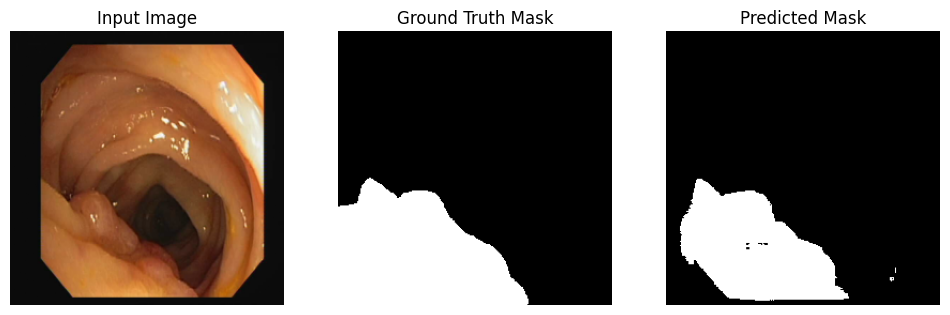

In [31]:
import matplotlib.pyplot as plt
import torch

# Put model in eval mode
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"

# Pick one sample from the dataset
sample_idx = 0
img, mask = train_dataset[sample_idx]  # img: tensor [C,H,W], mask: tensor [1,H,W]

# Move image to device and add batch dimension
img_input = img.unsqueeze(0).to(device)

# Forward pass
with torch.no_grad():
    pred_mask = model(img_input)          # [1, 1, H, W]
    pred_mask = pred_mask.squeeze(0).cpu()  # [1, H, W]

# Convert mask to numpy for plotting
img_np = img.permute(1, 2, 0).numpy()      # [H, W, C]
mask_np = mask.squeeze(0).numpy()          # [H, W]
pred_np = (pred_mask.squeeze(0).numpy() > 0.5).astype(float)  # threshold at 0.5

# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(img_np)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(mask_np, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Predicted Mask")
plt.imshow(pred_np, cmap="gray")
plt.axis("off")

plt.show()

# Sample predicitons with visualizations:

Sample 1:
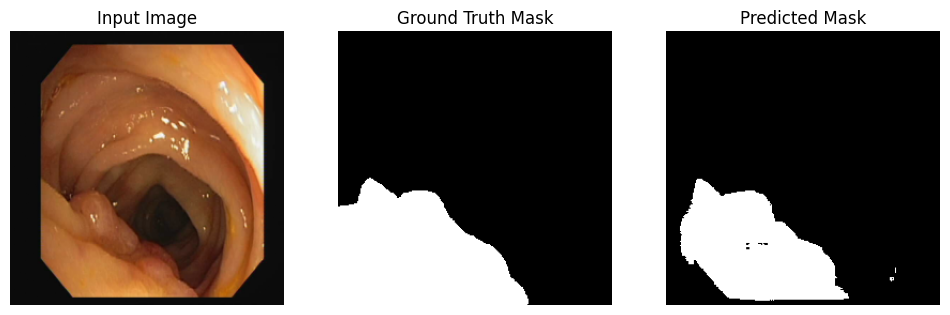![image.png]()

Sample 2:
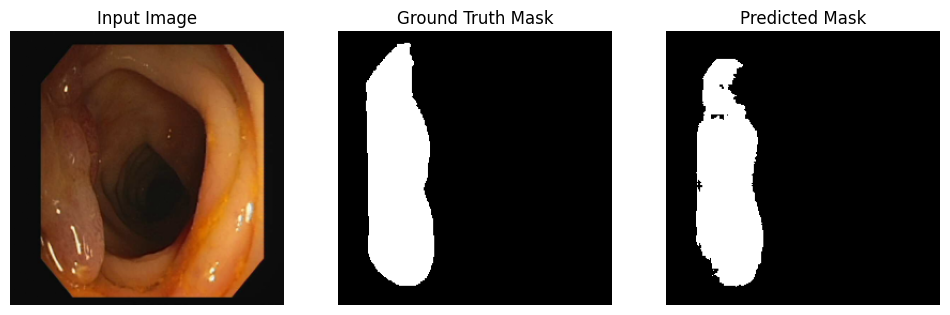

Sample 3:
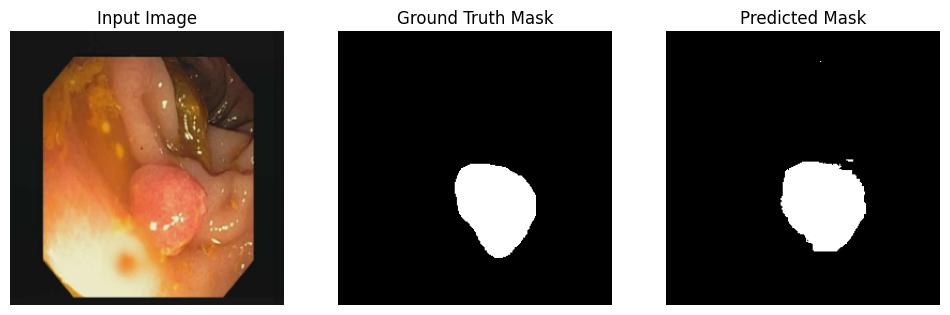

# As they did in the paper, I will implement Mean IoU measures for the test set.

In [27]:
import torch

def iou_score(pred_mask, true_mask, threshold=0.5, eps=1e-6):
    """
    Computes IoU for a single pair of predicted and ground truth masks.

    Args:
        pred_mask: tensor [H, W] or [1, H, W], predicted probabilities
        true_mask: tensor [H, W] or [1, H, W], ground truth mask (0 or 1)
        threshold: threshold to binarize prediction
        eps: small value to avoid division by zero
    Returns:
        iou: IoU score for this sample
    """
    # Binarize predictions
    pred_bin = (pred_mask > threshold).float()
    true_mask = true_mask.float()

    # Flatten
    pred_bin = pred_bin.view(-1)
    true_mask = true_mask.view(-1)

    # Intersection and union
    intersection = (pred_bin * true_mask).sum()
    union = pred_bin.sum() + true_mask.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    return iou

In [38]:
def mean_iou_fn(model, dataloader, device="cuda"):
    model.eval()
    iou_scores = []

    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)

            for pred, mask in zip(preds, masks):
                iou = iou_score(pred.squeeze(0), mask.squeeze(0))
                iou_scores.append(iou.item())

    mean_iou_value = sum(iou_scores) / len(iou_scores)
    return mean_iou_value

#Initial Results

In [29]:
mean_iou_val = mean_iou_fn(model, test_loader, device=device)
print(f"Mean IoU on training set: {mean_iou_val:.4f}")

Mean IoU on training set: 0.7737


Mean IoU on training set: 0.7737 (This isn't great. We will try to do better).

#Improvements

IoU Loss

Random Image Transformations

Tuned Hyperparameters

In [32]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [33]:
# Dice loss
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    return 1 - (2 * intersection + smooth) / (union + smooth)

# Combined loss
def bce_dice_loss(pred, target):
    bce = nn.BCELoss()(pred, target)
    d_loss = dice_loss(pred, target)
    return bce + d_loss

In [40]:
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 25

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    iou_scores = []

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)

        loss = bce_dice_loss(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # IoU per batch
        for pred, mask in zip(preds, masks):
            iou_scores.append(iou_score(pred.squeeze(0), mask.squeeze(0)).item())

    mean_iou = np.mean(iou_scores)
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss/len(train_loader):.4f} | Mean IoU: {mean_iou:.4f}")

Epoch [1/25] | Loss: 0.0667 | Mean IoU: 0.9104
Epoch [2/25] | Loss: 0.0595 | Mean IoU: 0.9196
Epoch [3/25] | Loss: 0.0553 | Mean IoU: 0.9245
Epoch [4/25] | Loss: 0.0485 | Mean IoU: 0.9347
Epoch [5/25] | Loss: 0.1015 | Mean IoU: 0.8898
Epoch [6/25] | Loss: 0.1427 | Mean IoU: 0.8457
Epoch [7/25] | Loss: 0.0634 | Mean IoU: 0.9149
Epoch [8/25] | Loss: 0.0445 | Mean IoU: 0.9375
Epoch [9/25] | Loss: 0.0426 | Mean IoU: 0.9406
Epoch [10/25] | Loss: 0.0422 | Mean IoU: 0.9427
Epoch [11/25] | Loss: 0.0428 | Mean IoU: 0.9405
Epoch [12/25] | Loss: 0.0437 | Mean IoU: 0.9416
Epoch [13/25] | Loss: 0.0793 | Mean IoU: 0.8995
Epoch [14/25] | Loss: 0.0791 | Mean IoU: 0.9008
Epoch [15/25] | Loss: 0.0783 | Mean IoU: 0.9012
Epoch [16/25] | Loss: 0.0498 | Mean IoU: 0.9327
Epoch [17/25] | Loss: 0.0397 | Mean IoU: 0.9435
Epoch [18/25] | Loss: 0.0388 | Mean IoU: 0.9459
Epoch [19/25] | Loss: 0.0355 | Mean IoU: 0.9499
Epoch [20/25] | Loss: 0.0366 | Mean IoU: 0.9503
Epoch [21/25] | Loss: 0.0909 | Mean IoU: 0.8943
E

# 50 Epochs

```
Epoch [1/50] | Loss: 0.1884 | Mean IoU: 0.8003
Epoch [2/50] | Loss: 0.1744 | Mean IoU: 0.8060
Epoch [3/50] | Loss: 0.1401 | Mean IoU: 0.8365
Epoch [4/50] | Loss: 0.1575 | Mean IoU: 0.8217
Epoch [5/50] | Loss: 0.1399 | Mean IoU: 0.8359
Epoch [6/50] | Loss: 0.1150 | Mean IoU: 0.8589
Epoch [7/50] | Loss: 0.1216 | Mean IoU: 0.8567
Epoch [8/50] | Loss: 0.1670 | Mean IoU: 0.8041
Epoch [9/50] | Loss: 0.1182 | Mean IoU: 0.8579
Epoch [10/50] | Loss: 0.1285 | Mean IoU: 0.8396
Epoch [11/50] | Loss: 0.0997 | Mean IoU: 0.8707
Epoch [12/50] | Loss: 0.1071 | Mean IoU: 0.8656
Epoch [13/50] | Loss: 0.1001 | Mean IoU: 0.8754
Epoch [14/50] | Loss: 0.0934 | Mean IoU: 0.8853
Epoch [15/50] | Loss: 0.1292 | Mean IoU: 0.8472
Epoch [16/50] | Loss: 0.1300 | Mean IoU: 0.8519
Epoch [17/50] | Loss: 0.1128 | Mean IoU: 0.8596
Epoch [18/50] | Loss: 0.0942 | Mean IoU: 0.8823
Epoch [19/50] | Loss: 0.0857 | Mean IoU: 0.8900
Epoch [20/50] | Loss: 0.0749 | Mean IoU: 0.9032
Epoch [21/50] | Loss: 0.0937 | Mean IoU: 0.8805
Epoch [22/50] | Loss: 0.1518 | Mean IoU: 0.8370
Epoch [23/50] | Loss: 0.1428 | Mean IoU: 0.8400
Epoch [24/50] | Loss: 0.0994 | Mean IoU: 0.8786
Epoch [25/50] | Loss: 0.0917 | Mean IoU: 0.8784
Epoch [26/50] | Loss: 0.0693 | Mean IoU: 0.9088
Epoch [27/50] | Loss: 0.0791 | Mean IoU: 0.8961
Epoch [28/50] | Loss: 0.0754 | Mean IoU: 0.9016
Epoch [29/50] | Loss: 0.0690 | Mean IoU: 0.9094
Epoch [30/50] | Loss: 0.0599 | Mean IoU: 0.9197
Epoch [31/50] | Loss: 0.0587 | Mean IoU: 0.9195
Epoch [32/50] | Loss: 0.0809 | Mean IoU: 0.8949
Epoch [33/50] | Loss: 0.0748 | Mean IoU: 0.9038
Epoch [34/50] | Loss: 0.0668 | Mean IoU: 0.9129
Epoch [35/50] | Loss: 0.0730 | Mean IoU: 0.9094
Epoch [36/50] | Loss: 0.0626 | Mean IoU: 0.9162
Epoch [37/50] | Loss: 0.0718 | Mean IoU: 0.9122
Epoch [38/50] | Loss: 0.0659 | Mean IoU: 0.9129
Epoch [39/50] | Loss: 0.0528 | Mean IoU: 0.9272
Epoch [40/50] | Loss: 0.0599 | Mean IoU: 0.9215
Epoch [41/50] | Loss: 0.0688 | Mean IoU: 0.9074
Epoch [42/50] | Loss: 0.0494 | Mean IoU: 0.9298
Epoch [43/50] | Loss: 0.0475 | Mean IoU: 0.9339
Epoch [44/50] | Loss: 0.0513 | Mean IoU: 0.9315
Epoch [45/50] | Loss: 0.0574 | Mean IoU: 0.9286
Epoch [46/50] | Loss: 0.1384 | Mean IoU: 0.8433
Epoch [47/50] | Loss: 0.0819 | Mean IoU: 0.8956
Epoch [48/50] | Loss: 0.0567 | Mean IoU: 0.9274
Epoch [49/50] | Loss: 0.0920 | Mean IoU: 0.8829
Epoch [50/50] | Loss: 0.0591 | Mean IoU: 0.9222
```

# 25 Epochs


```
Epoch [1/25] | Loss: 0.0667 | Mean IoU: 0.9104
Epoch [2/25] | Loss: 0.0595 | Mean IoU: 0.9196
Epoch [3/25] | Loss: 0.0553 | Mean IoU: 0.9245
Epoch [4/25] | Loss: 0.0485 | Mean IoU: 0.9347
Epoch [5/25] | Loss: 0.1015 | Mean IoU: 0.8898
Epoch [6/25] | Loss: 0.1427 | Mean IoU: 0.8457
Epoch [7/25] | Loss: 0.0634 | Mean IoU: 0.9149
Epoch [8/25] | Loss: 0.0445 | Mean IoU: 0.9375
Epoch [9/25] | Loss: 0.0426 | Mean IoU: 0.9406
Epoch [10/25] | Loss: 0.0422 | Mean IoU: 0.9427
Epoch [11/25] | Loss: 0.0428 | Mean IoU: 0.9405
Epoch [12/25] | Loss: 0.0437 | Mean IoU: 0.9416
Epoch [13/25] | Loss: 0.0793 | Mean IoU: 0.8995
Epoch [14/25] | Loss: 0.0791 | Mean IoU: 0.9008
Epoch [15/25] | Loss: 0.0783 | Mean IoU: 0.9012
Epoch [16/25] | Loss: 0.0498 | Mean IoU: 0.9327
Epoch [17/25] | Loss: 0.0397 | Mean IoU: 0.9435
Epoch [18/25] | Loss: 0.0388 | Mean IoU: 0.9459
Epoch [19/25] | Loss: 0.0355 | Mean IoU: 0.9499
Epoch [20/25] | Loss: 0.0366 | Mean IoU: 0.9503
Epoch [21/25] | Loss: 0.0909 | Mean IoU: 0.8943
Epoch [22/25] | Loss: 0.0467 | Mean IoU: 0.9387
Epoch [23/25] | Loss: 0.0907 | Mean IoU: 0.8875
Epoch [24/25] | Loss: 0.0812 | Mean IoU: 0.9005
Epoch [25/25] | Loss: 0.0660 | Mean IoU: 0.9261
```



In [41]:
mean_iou_val = mean_iou_fn(model, test_loader, device=device)
print(f"Mean IoU on training set: {mean_iou_val:.4f}")

Mean IoU on training set: 0.8106


# Results
Mean IoU on training set: 0.7970 (50 epochs). (Likely suffering from overfitting).

Mean IoU on training set: 0.8106 (25 epochs).

This is not as good as the results from the article published in the International Journal of Scientific Research in Science and Technology that found that U-Net achieved a Mean IoU score of 0.9897 and that DeepLab displayed a slightly less impressive IoU score of 0.9676. However, the results are overall pretty good.



# Final Visualization

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

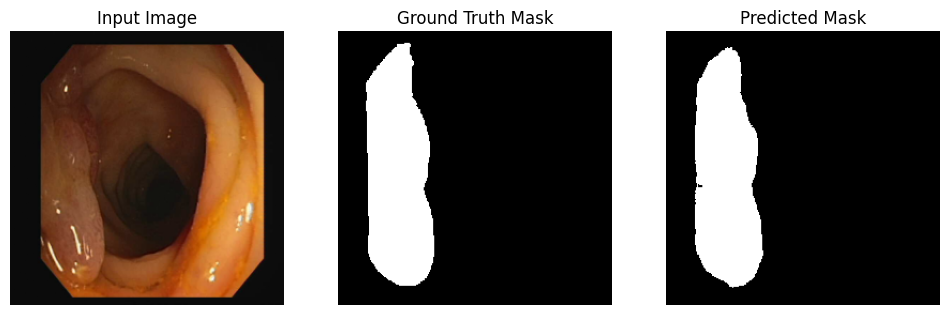

In [44]:
import matplotlib.pyplot as plt
import torch

# Put model in eval mode
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"

# Pick one sample from the dataset
sample_idx = 1
img, mask = train_dataset[sample_idx]  # img: tensor [C,H,W], mask: tensor [1,H,W]

# Move image to device and add batch dimension
img_input = img.unsqueeze(0).to(device)

# Forward pass
with torch.no_grad():
    pred_mask = model(img_input)          # [1, 1, H, W]
    pred_mask = pred_mask.squeeze(0).cpu()  # [1, H, W]

# Convert mask to numpy for plotting
img_np = img.permute(1, 2, 0).numpy()      # [H, W, C]
mask_np = mask.squeeze(0).numpy()          # [H, W]
pred_np = (pred_mask.squeeze(0).numpy() > 0.5).astype(float)  # threshold at 0.5

# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(img_np)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(mask_np, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Predicted Mask")
plt.imshow(pred_np, cmap="gray")
plt.axis("off")


# Sample 1:
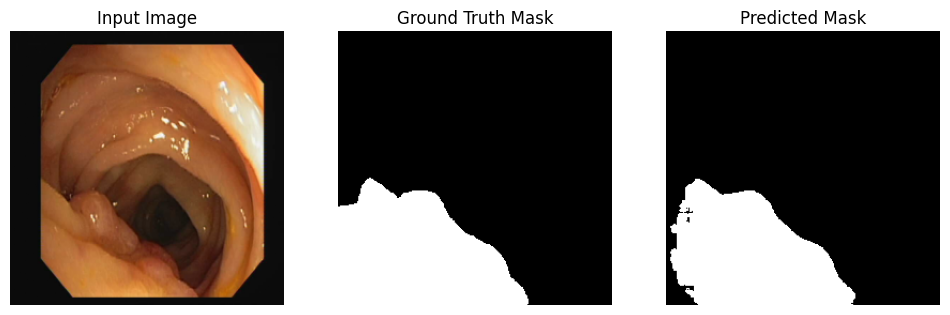

# Sample 2
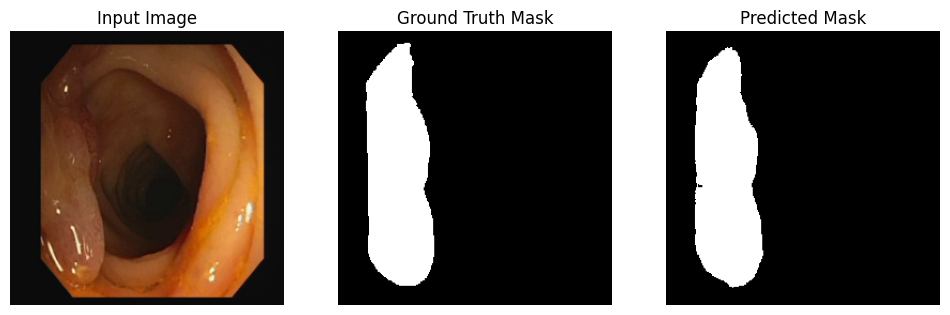

# Sample 3
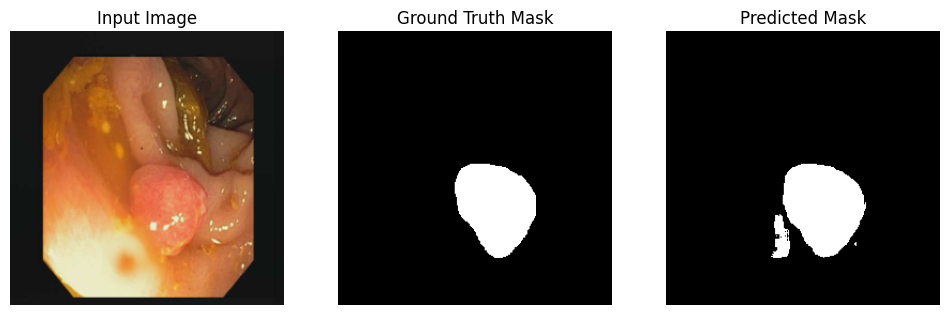

